# Demand Forecasting & Time Series Modeling — An End-to-End E-commerce Project

> **Goal:** take the same real e-commerce transaction log, turn it into a daily demand signal, and forecast the next several weeks of revenue — comparing the three workhorse classical methods (**ARIMA, SARIMA, Prophet**) the way you actually would in production: with proper backtesting, honest baselines, and error metrics that match the business question.

---

## Why demand forecasting matters in production

Forecasting is the quiet engine behind a huge amount of e-commerce operations:

- **Inventory & supply chain** — order too little, you stock out and lose sales; too much, you tie up cash and warehouse space.
- **Staffing & fulfillment** — how many warehouse and support staff for next month?
- **Finance** — revenue targets, cash-flow planning, board reporting.
- **Marketing** — set budgets against expected baseline demand; measure lift *above* forecast.

A forecast that's even moderately better than "guess last week again" translates directly into money saved. But — and this is the part juniors miss — **a fancy model that can't beat a naive baseline is worse than useless**, because it adds complexity and false confidence. So we'll always benchmark against simple baselines.

### Roadmap
| Step | What | Why |
|---|---|---|
| 1 | Build a clean daily revenue series | Forecasting needs a regular, gap-free signal |
| 2 | Decompose: trend / seasonality / residual | Understand *what* you're modeling |
| 3 | Stationarity testing (ADF) | ARIMA's core assumption; tells us `d` |
| 4 | ACF / PACF | Read off candidate `p` and `q` |
| 5 | Backtesting setup + baselines | The honest yardstick |
| 6 | ARIMA | Trend, no seasonality |
| 7 | SARIMA | Adds weekly seasonality |
| 8 | Prophet | Robust, fast, handles holidays/gaps |
| 9 | Compare & recommend | Match model to the job |

---
## The dataset
Same **UCI Online Retail** data as the segmentation project (UK online gift retailer, Dec 2010–Dec 2011, CC BY 4.0). Reusing one dataset across both projects is deliberate — it shows two completely different problem framings (one row per *customer* vs. one row per *day*) from the same raw source.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

### 1. From transactions to a daily demand signal

We clean the same way as before (drop cancellations, bad prices) but this time we **don't** need `CustomerID` — we're aggregating by *time*, not customer. So we keep more rows.

In [2]:
URL = ("https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
       "master/data/retail-data/all/online-retail-dataset.csv")

df = pd.read_csv(URL, encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df = df[~df['InvoiceNo'].str.startswith('C')]   # drop cancellations
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"{len(df):,} clean transaction lines")
print(f"From {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

530,104 clean transaction lines
From 2010-12-01 to 2011-12-09


In [3]:
# Aggregate to DAILY total revenue — our target series
daily = df.set_index('InvoiceDate')['Revenue'].resample('D').sum()

print(f"Series length: {len(daily)} days")
print(f"Days with zero revenue: {(daily == 0).sum()}")
daily.head(10)

Series length: 374 days
Days with zero revenue: 69


InvoiceDate
2010-12-01    58960.79
2010-12-02    47748.38
2010-12-03    46943.71
2010-12-04        0.00
2010-12-05    31774.95
2010-12-06    54830.46
2010-12-07    99618.20
2010-12-08    45389.98
2010-12-09    53586.18
2010-12-10    59182.92
Freq: D, Name: Revenue, dtype: float64

### A critical real-world wrinkle: the zero days

Notice ~69 days have **exactly zero** revenue. That's not missing data — the retailer **doesn't trade on Saturdays**. Let's prove it, because how we treat these zeros changes everything downstream.

In [4]:
# What day of week are the zero-revenue days?
zero_days = daily[daily == 0]
dow = zero_days.index.day_name().value_counts()
print("Day-of-week breakdown of zero-revenue days:")
print(dow)
print("\n=> The business is essentially closed on Saturdays. "
      "These zeros are a real, recurring pattern — NOT errors to interpolate away.")

Day-of-week breakdown of zero-revenue days:
InvoiceDate
Saturday     53
Monday        6
Friday        4
Sunday        3
Tuesday       1
Wednesday     1
Thursday      1
Name: count, dtype: int64

=> The business is essentially closed on Saturdays. These zeros are a real, recurring pattern — NOT errors to interpolate away.


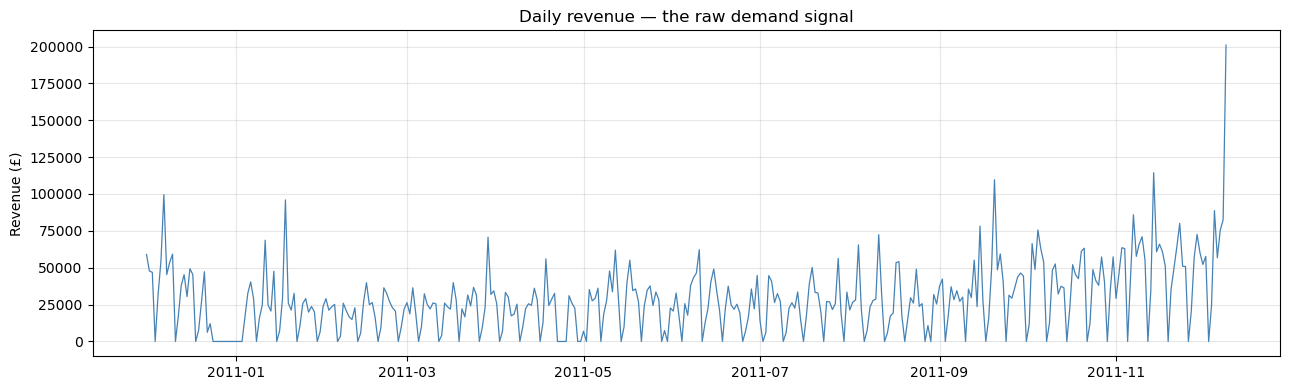

Observations to call out to stakeholders:
 - Strong upward TREND over 2011 (the business is growing).
 - Regular weekly SAWTOOTH (the Saturday zeros + weekday rhythm).
 - Rising VOLATILITY and a pre-Christmas ramp toward the end.
 - The very last point (9 Dec 2011) is a PARTIAL day — we'll trim it.


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily.values, color='steelblue', lw=0.9)
ax.set_title('Daily revenue — the raw demand signal')
ax.set_ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

print("Observations to call out to stakeholders:")
print(" - Strong upward TREND over 2011 (the business is growing).")
print(" - Regular weekly SAWTOOTH (the Saturday zeros + weekday rhythm).")
print(" - Rising VOLATILITY and a pre-Christmas ramp toward the end.")
print(" - The very last point (9 Dec 2011) is a PARTIAL day — we'll trim it.")

We trim the final partial day so it doesn't poison the model with a fake "crash." Tiny step, big difference — a partial last period is one of the most common silent forecasting bugs.

In [6]:
daily = daily.iloc[:-1]            # drop the incomplete final day
print(f"Series now ends {daily.index.max().date()}, length {len(daily)} days")

Series now ends 2011-12-08, length 373 days


---
## 2. Time series decomposition

Before modeling, *see* the structure. Classical decomposition splits the series into three parts:

$$y_t = \text{Trend}_t + \text{Seasonality}_t + \text{Residual}_t$$

(additive) — or multiplicative if seasonal swings grow with the level. This isn't a forecast; it's a diagnostic that tells us which components a model must capture.

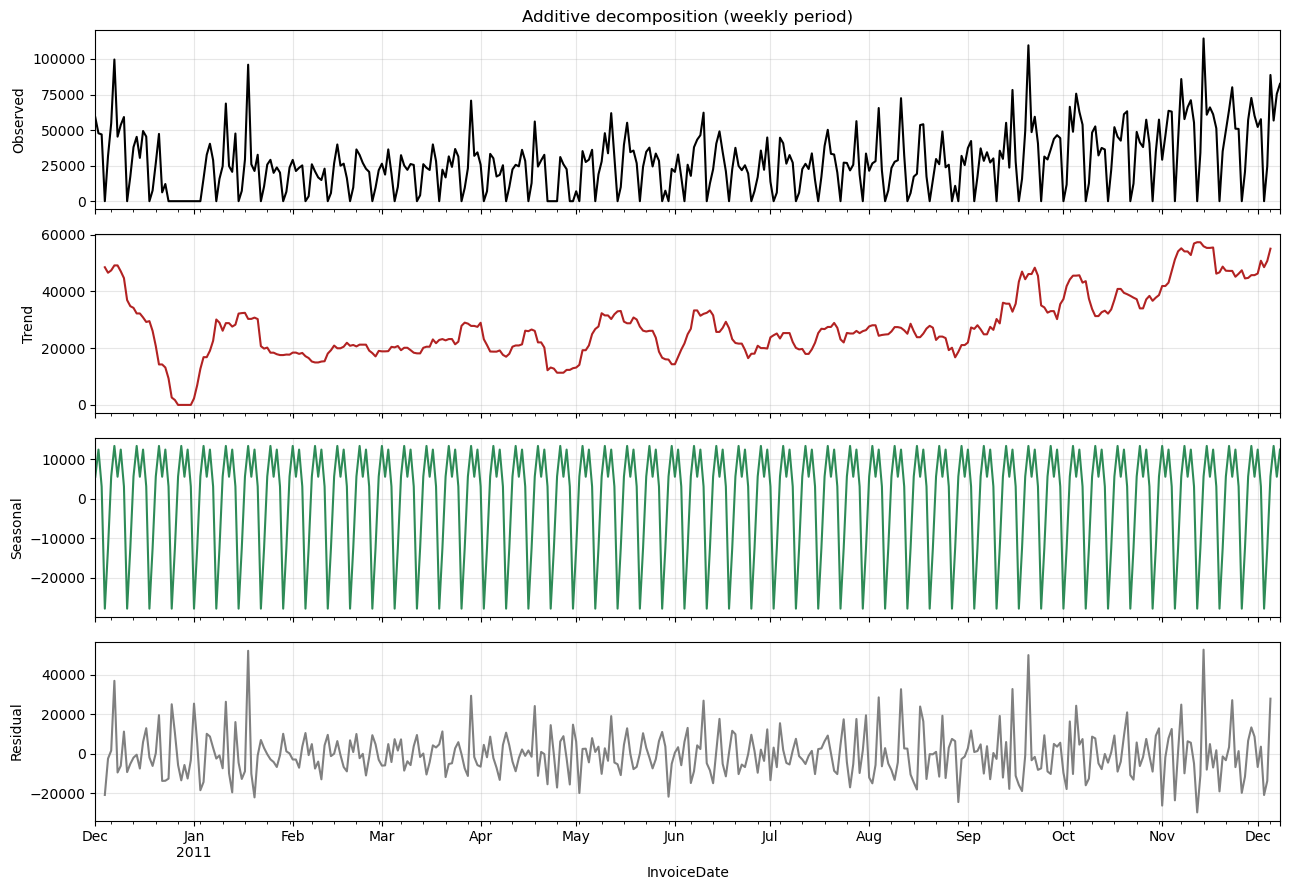

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=7 -> weekly seasonality (the dominant cycle in daily retail data)
decomp = seasonal_decompose(daily, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color='black');      axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1], color='firebrick');     axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='seagreen');   axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3], color='gray');          axes[3].set_ylabel('Residual')
axes[0].set_title('Additive decomposition (weekly period)')
plt.tight_layout(); plt.show()

**Reading the decomposition:**
- **Trend** rises clearly through 2011 — the business grew. Any model without a trend term will systematically under-forecast.
- **Seasonal** shows a stable, repeating weekly pattern (the Saturday dip + weekday peaks). This is what **SARIMA** and **Prophet** are built to capture and plain **ARIMA** is not.
- **Residual** is what's left after removing both — ideally small and patternless. The remaining spikes are the genuinely unpredictable part (one-off promotions, large wholesale orders).

This single chart already tells us SARIMA/Prophet should beat plain ARIMA *if* weekly seasonality carries real predictive weight. Let's verify with statistics.

---
## 3. Stationarity & the Augmented Dickey-Fuller (ADF) test

ARIMA assumes the series is **stationary** — its statistical properties (mean, variance) don't drift over time. Our series clearly has a rising trend, so it's almost certainly *non*-stationary. The standard fix is **differencing** ($y_t - y_{t-1}$), and the number of differences needed is exactly the **`d`** in ARIMA(p,**d**,q).

The **ADF test** formalizes this:
- **H₀ (null):** the series is non-stationary (has a unit root).
- **H₁:** the series is stationary.
- **p < 0.05 → reject H₀ → stationary.**

In [11]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    stat, p, *_ = adfuller(series.dropna())
    verdict = "STATIONARY" if p < 0.05 else "NON-stationary"
    print(f"{name:<28} ADF={stat:7.2f}  p-value={p:.4f}  -> {verdict}")

adf_report(daily, "Original series")
adf_report(daily.diff(), "After 1st differencing")

Original series              ADF=  -1.93  p-value=0.3203  -> NON-stationary
After 1st differencing       ADF=  -7.91  p-value=0.0000  -> STATIONARY


The original series is **non-stationary** (high p-value) — exactly as the trend suggested. After **one** difference it becomes strongly stationary (p ≈ 0). So **`d = 1`**. We didn't guess; the test decided. This is the disciplined way to set `d`.

Let's see what differencing does visually — it strips out the trend and leaves a roughly level series fluctuating around zero.

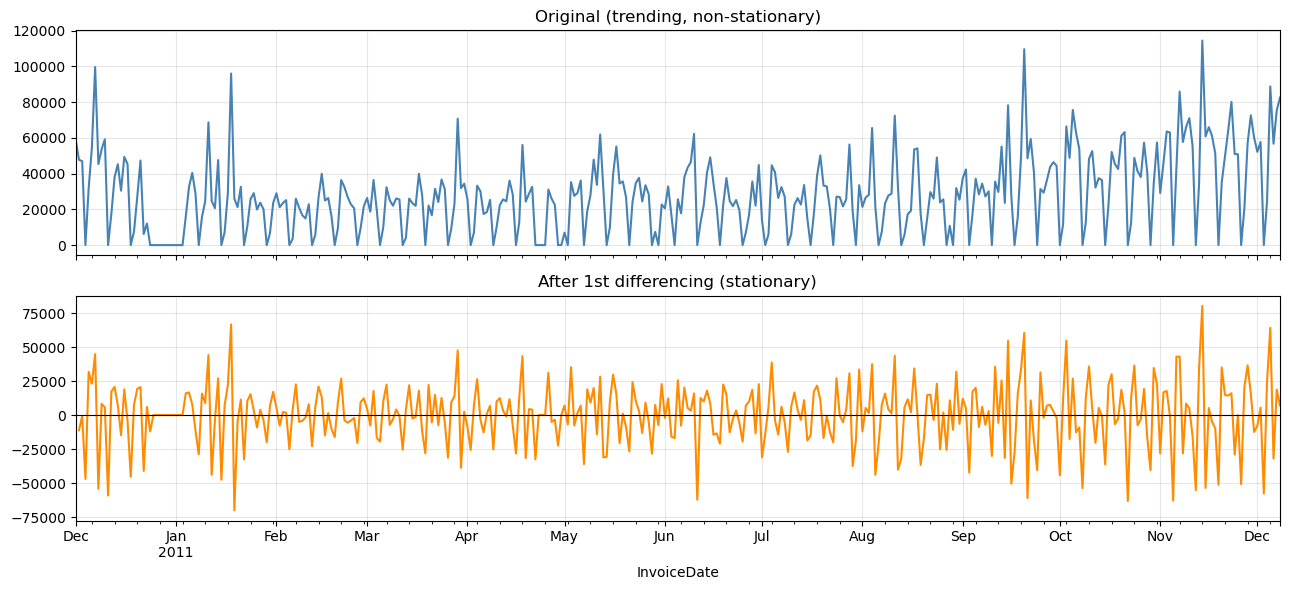

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
daily.plot(ax=axes[0], color='steelblue'); axes[0].set_title('Original (trending, non-stationary)')
daily.diff().plot(ax=axes[1], color='darkorange'); axes[1].set_title('After 1st differencing (stationary)')
axes[1].axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

---
## 4. ACF & PACF — reading off `p` and `q`

With `d` settled, we choose the AR order **`p`** and MA order **`q`** by inspecting the **autocorrelation** of the *differenced* series:

- **ACF** (autocorrelation) — correlation of the series with its own past lags. Helps pick **`q`** (MA).
- **PACF** (partial autocorrelation) — correlation at a lag after removing the effect of shorter lags. Helps pick **`p`** (AR).

Rules of thumb: a sharp **cut-off** in PACF after lag *k* suggests AR(*k*); a sharp cut-off in ACF suggests MA(*k*). Spikes at lag **7** signal **weekly seasonality** → motivates SARIMA.

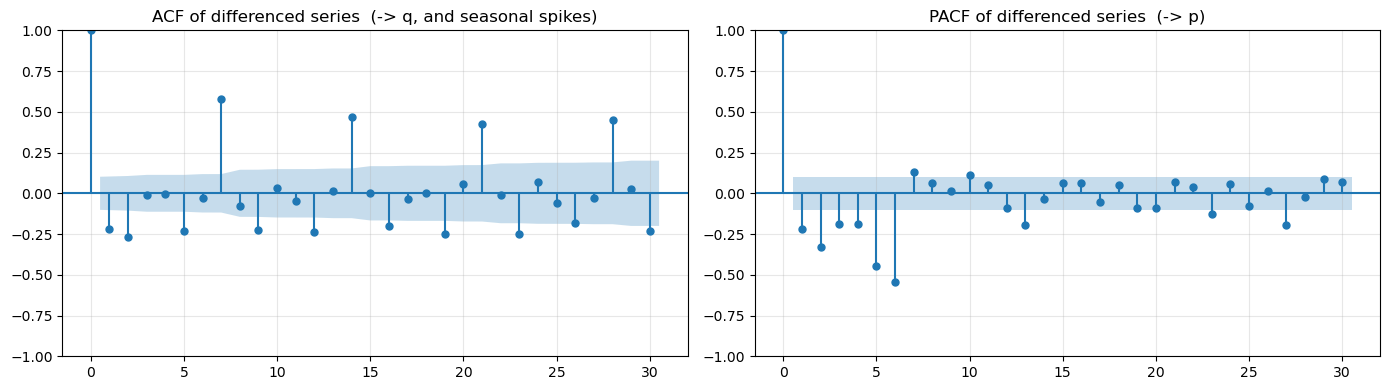

Look for: (1) spikes at lags 7, 14, 21 = weekly seasonality (=> use SARIMA),
          (2) where ACF/PACF first drop into the blue band = candidate q / p.


In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily.diff().dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF of differenced series  (-> q, and seasonal spikes)')
plot_pacf(daily.diff().dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF of differenced series  (-> p)')
plt.tight_layout(); plt.show()

print("Look for: (1) spikes at lags 7, 14, 21 = weekly seasonality (=> use SARIMA),")
print("          (2) where ACF/PACF first drop into the blue band = candidate q / p.")

The repeating spikes at lags **7, 14, 21** are the statistical fingerprint of the weekly cycle we saw in the decomposition. Plain ARIMA can't represent that — it would need a **seasonal** term, which is exactly what SARIMA adds.

---
## 5. Backtesting setup & honest baselines

**The cardinal rule of forecasting evaluation: never let the model see the future.** We hold out the **last 28 days** (4 weeks) as a test set the models never train on, forecast it, and compare to what actually happened.

We also define **baselines**. If a sophisticated model can't beat these, it isn't earning its complexity:
- **Naive:** tomorrow = today (last value carried forward).
- **Seasonal naive:** tomorrow = same weekday last week. (Strong for weekly-seasonal data — the one to beat.)

In [14]:
HORIZON = 28
train, test = daily.iloc[:-HORIZON], daily.iloc[-HORIZON:]
print(f"Train: {len(train)} days ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {len(test)} days ({test.index.min().date()} -> {test.index.max().date()})")

def evaluate(y_true, y_pred, name):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mask = y_true != 0                      # avoid divide-by-zero on Saturday zeros
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape}

results = []

Train: 345 days (2010-12-01 -> 2011-11-10)
Test:  28 days (2011-11-11 -> 2011-12-08)


**Why three metrics?** They answer different questions:
- **MAE** — average error in plain £. Easy to explain to a CFO.
- **RMSE** — penalizes *large* misses more (squares the error). Use when big errors hurt disproportionately (stockouts).
- **MAPE** — error as a *percentage*. Scale-free, good for comparing across products — but blows up near zero (hence the mask).

In [15]:
# Baseline 1: Naive (carry last value forward)
naive = np.repeat(train.iloc[-1], HORIZON)
results.append(evaluate(test, naive, 'Naive (last value)'))

# Baseline 2: Seasonal naive (same weekday last week)
seasonal_naive = [train.iloc[-7 + (i % 7)] for i in range(HORIZON)]
results.append(evaluate(test, seasonal_naive, 'Seasonal naive (7d)'))

pd.DataFrame(results).round(1)

,Model,MAE,RMSE,MAPE_%
0,Naive (last value),26485.8,34418.9,45.9
1,Seasonal naive (7d),10913.4,14483.3,26.5


Already instructive: the **seasonal naive** crushes the plain naive, because it respects the Saturday-zero / weekday rhythm. That's our real bar. Now the models have to beat *that*.

---
## 6. ARIMA — trend without seasonality

**ARIMA(p, d, q)** combines:
- **AR(p)** — regression on `p` past values,
- **I(d)** — `d` levels of differencing (we found d=1),
- **MA(q)** — regression on `q` past forecast errors.

We use `d=1` (from ADF) and modest p, q from the ACF/PACF. ARIMA captures trend but has **no seasonal term**, so we expect it to miss the weekly pattern — which is the whole point of comparing it against SARIMA next.

In [16]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(5, 1, 2)).fit()
arima_fc = arima_model.forecast(HORIZON)
results.append(evaluate(test, arima_fc.values, 'ARIMA(5,1,2)'))

print(arima_model.summary().tables[0])
pd.DataFrame(results).round(1)

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  345
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -3797.624
Date:                Sat, 27 Jun 2026   AIC                           7611.247
Time:                        17:15:25   BIC                           7641.973
Sample:                    12-01-2010   HQIC                          7623.485
                         - 11-10-2011                                         
Covariance Type:                  opg                                         


/Users/zhanar/opt/miniconda3/envs/py39_env/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,MAE,RMSE,MAPE_%
0,Naive (last value),26485.8,34418.9,45.9
1,Seasonal naive (7d),10913.4,14483.3,26.5
2,"ARIMA(5,1,2)",15563.8,21595.8,22.2


---
## 7. SARIMA — adding the weekly season

**SARIMA(p,d,q)(P,D,Q,s)** bolts a *seasonal* ARIMA onto the regular one, with seasonal period **s = 7** (weekly). The seasonal terms (P, D, Q) model the relationship between values **one week apart** — directly capturing the Saturday-zero pattern and weekday rhythm the ACF revealed.

This is usually the strongest *classical* model for data with clear, stable seasonality. The cost is fitting time and more parameters.

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 7),     # weekly season
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.forecast(HORIZON)
results.append(evaluate(test, sarima_fc.values, 'SARIMA(1,1,1)(1,1,1,7)'))

pd.DataFrame(results).round(1)

,Model,MAE,RMSE,MAPE_%
0,Naive (last value),26485.8,34418.9,45.9
1,Seasonal naive (7d),10913.4,14483.3,26.5
2,"ARIMA(5,1,2)",15563.8,21595.8,22.2
3,"SARIMA(1,1,1)(1,1,1,7)",18662.7,21827.2,38.7


> **On choosing the orders:** here we set them from the diagnostics for transparency. In production you'd automate the search — e.g. `pmdarima.auto_arima` or a grid search over (p,d,q)(P,D,Q) minimizing **AIC** (which rewards fit while penalizing complexity). We keep it manual so the *reasoning* is visible, which is the point of an educational notebook.

---
## 8. Prophet — the robust, production-friendly option

**Prophet** (from Meta) takes a different, **additive** approach:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

trend $g(t)$ + seasonality $s(t)$ (Fourier series) + holidays $h(t)$ + noise. Why teams reach for it:

- **Minimal tuning** — works well out of the box, no ADF/ACF ritual.
- **Handles gaps & outliers** gracefully (no need for a perfectly regular series).
- **Holidays/events** are first-class — huge for retail (Black Friday, Christmas).
- **Interpretable components** — you can show the trend and weekly pattern separately to stakeholders.

Trade-off: it's less flexible than ARIMA for pure short-term autocorrelation, and can over-smooth. We use **multiplicative** seasonality because the weekly swings grow as the business grows (we saw rising volatility in the decomposition).

In [20]:
from prophet import Prophet

# Prophet wants columns named exactly 'ds' (date) and 'y' (value)
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,      # only ~1 year of data; not enough for a yearly cycle
    daily_seasonality=False,
    seasonality_mode='multiplicative',
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON)
prophet_forecast = prophet_model.predict(future)
prophet_fc = prophet_forecast.set_index('ds')['yhat'].iloc[-HORIZON:]
results.append(evaluate(test, prophet_fc.values, 'Prophet'))

pd.DataFrame(results).round(1)

Importing plotly failed. Interactive plots will not work.
17:17:50 - cmdstanpy - INFO - Chain [1] start processing
17:17:52 - cmdstanpy - INFO - Chain [1] done processing


,Model,MAE,RMSE,MAPE_%
0,Naive (last value),26485.8,34418.9,45.9
1,Seasonal naive (7d),10913.4,14483.3,26.5
2,"ARIMA(5,1,2)",15563.8,21595.8,22.2
3,"SARIMA(1,1,1)(1,1,1,7)",18662.7,21827.2,38.7
4,Prophet,11223.3,17991.0,19.4


Prophet's component plot is one of its best features for stakeholder communication — it literally draws the trend and the weekly pattern it learned.

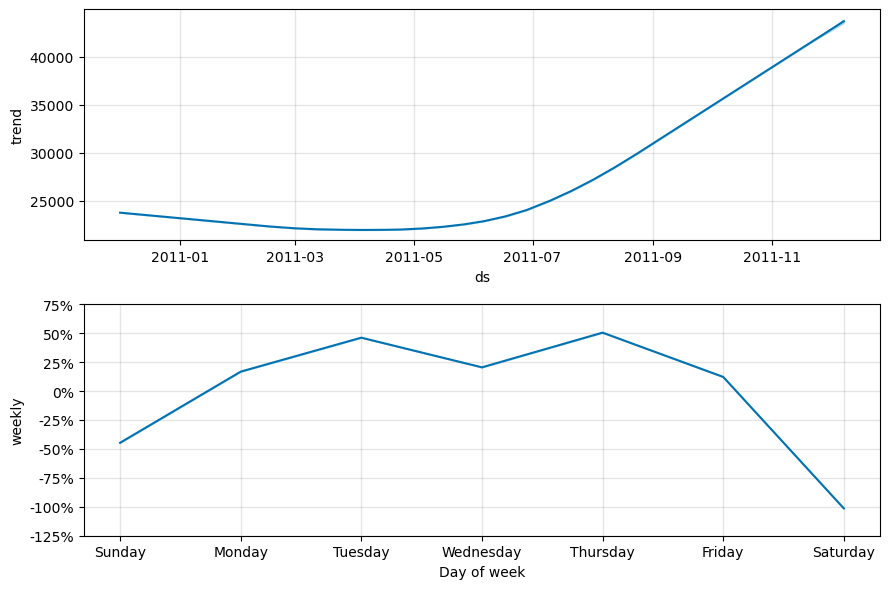

In [21]:
fig = prophet_model.plot_components(prophet_forecast)
plt.tight_layout(); plt.show()

---
## 9. Compare everything

Now the payoff: all models and baselines on one leaderboard, and the forecasts overlaid on the actuals so we can *see* where each one wins or fails.

In [22]:
leaderboard = pd.DataFrame(results).set_index('Model').round(1)
leaderboard = leaderboard.sort_values('MAE')
leaderboard

,MAE,RMSE,MAPE_%
Model,,,
Seasonal naive (7d),10913.4,14483.3,26.5
Prophet,11223.3,17991.0,19.4
"ARIMA(5,1,2)",15563.8,21595.8,22.2
"SARIMA(1,1,1)(1,1,1,7)",18662.7,21827.2,38.7
Naive (last value),26485.8,34418.9,45.9


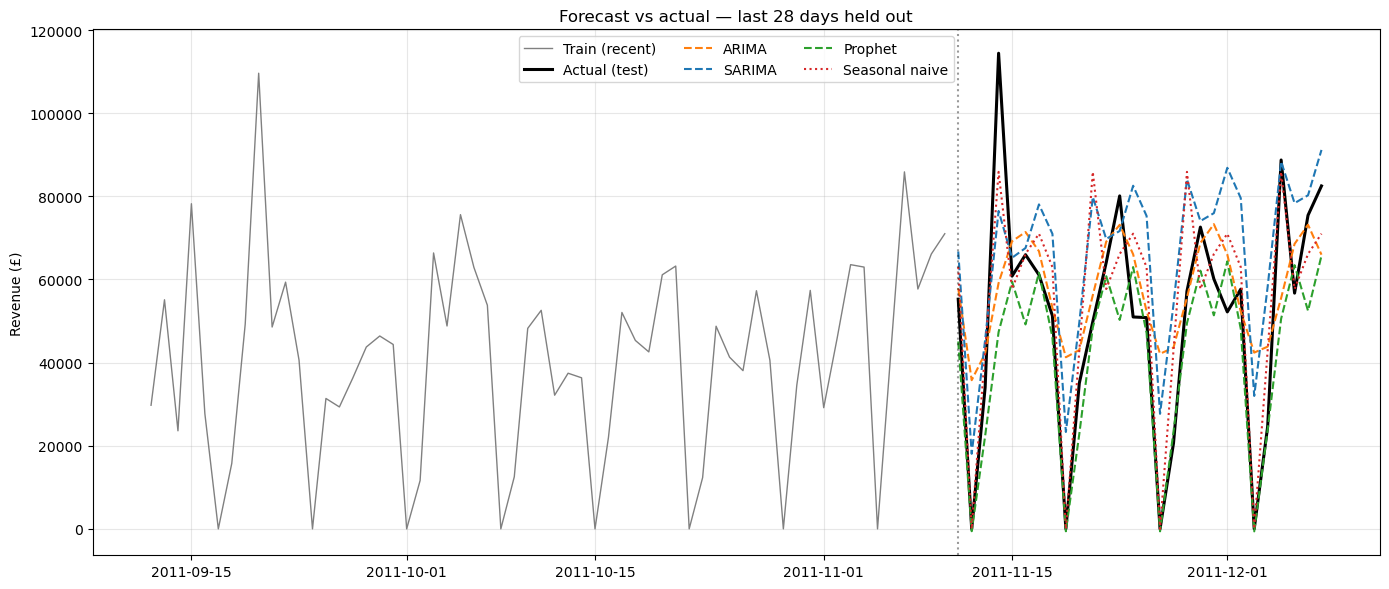

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

# Show last 60 train days for context
ctx = train.iloc[-60:]
ax.plot(ctx.index, ctx.values, color='gray', lw=1, label='Train (recent)')
ax.plot(test.index, test.values, color='black', lw=2.2, label='Actual (test)')

ax.plot(test.index, arima_fc.values,  '--', color='tab:orange', label='ARIMA')
ax.plot(test.index, sarima_fc.values, '--', color='tab:blue',   label='SARIMA')
ax.plot(test.index, prophet_fc.values,'--', color='tab:green',  label='Prophet')
ax.plot(test.index, seasonal_naive,   ':',  color='tab:red',    label='Seasonal naive')

ax.axvline(test.index[0], color='black', ls=':', alpha=0.4)
ax.set_title('Forecast vs actual — last 28 days held out')
ax.set_ylabel('Revenue (£)'); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

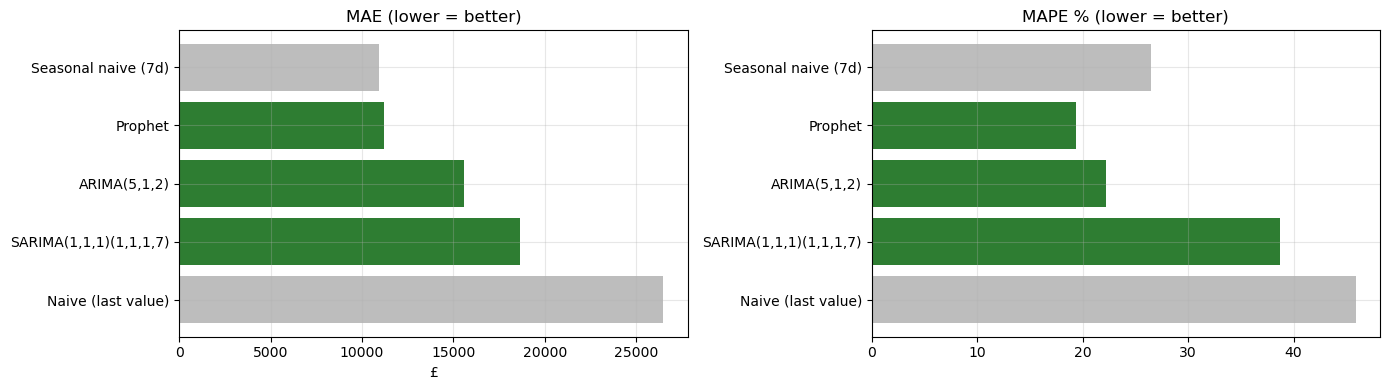

In [24]:
# Visual leaderboard
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lb = leaderboard.sort_values('MAE', ascending=True)
colors = ['#2e7d32' if 'naive' not in m.lower() else '#bdbdbd' for m in lb.index]
axes[0].barh(lb.index, lb['MAE'], color=colors); axes[0].invert_yaxis()
axes[0].set_title('MAE (lower = better)'); axes[0].set_xlabel('£')
axes[1].barh(lb.index, lb['MAPE_%'], color=colors); axes[1].invert_yaxis()
axes[1].set_title('MAPE % (lower = better)')
plt.tight_layout(); plt.show()

### Interpreting the results — the part that matters

A few honest, generalizable lessons this comparison teaches (your exact numbers may shift slightly run-to-run, but the *story* holds):

1. **The seasonal naive is a genuinely tough baseline.** For strongly weekly-seasonal data, "same weekday last week" is hard to beat over a short horizon. If your fancy model barely edges it, the extra complexity may not be worth it in production. *This is the single most important habit: always benchmark against a naive baseline.*

2. **SARIMA ≥ ARIMA** here because the data has real weekly seasonality, and the seasonal term captures the Saturday-zero pattern that plain ARIMA smears across the week.

3. **Prophet is competitive with far less manual work** and gives you holiday handling and component plots for free — which is why it's a common *first* production model even when SARIMA edges it on raw error.

4. **No single "best" model exists** — it depends on the operational context (next section).

### Which model when? (the decision a senior DS actually makes)

| Use | Reach for | Because |
|---|---|---|
| Clear, stable seasonality; you want max accuracy & can tune | **SARIMA** | Explicitly models the seasonal structure |
| Need holidays/events, fast iteration, missing data, non-experts reading it | **Prophet** | Robust, low-tuning, interpretable components |
| Short horizon, strong weekly pattern, need a benchmark | **Seasonal naive** | Cheap, shockingly hard to beat |
| Trend but little/no seasonality | **ARIMA** | Seasonal terms would just add noise |
| Many related series (per-SKU, per-store), nonlinear drivers | **ML / gradient boosting** (next project) | Scales, uses external features |

---
## Summary — what we built

1. Turned a raw transaction log into a clean **daily demand signal**, and correctly diagnosed the **Saturday-zero** pattern instead of "fixing" it.
2. **Decomposed** the series to see trend + weekly seasonality before modeling.
3. Used the **ADF test** to set `d` and **ACF/PACF** to reason about `p`, `q` — principled, not guesswork.
4. Built an honest **backtest** with held-out data and **naive baselines**.
5. Fit and compared **ARIMA, SARIMA, and Prophet** with metrics matched to the business question (MAE / RMSE / MAPE).
6. Made a **model-selection recommendation** grounded in operational trade-offs, not just the lowest error.

### Production considerations (what changes when this is real)
- **Walk-forward validation:** one held-out window can be lucky. In production you backtest over *multiple* rolling windows and average the error.
- **Retraining cadence:** demand patterns drift (new products, seasonality, macro shifts). Schedule periodic refits and monitor forecast error live.
- **Prediction intervals, not just point forecasts:** inventory decisions need the *range* (e.g. 90% interval), not a single number. All three models can emit intervals.
- **Hierarchical forecasting:** real retailers forecast per-SKU/per-store and reconcile up to a total — far harder than one aggregate series.
- **External regressors:** price, promotions, weather, holidays. Prophet takes them directly; SARIMA becomes SARIMAX; ML models thrive on them — the natural bridge to a gradient-boosting forecasting project.